In [54]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('postings.csv')

# Check basic info
df.shape

(6025, 11)

In [3]:
df.columns

Index(['job_title', 'company', 'job_location', 'job_link', 'first_seen',
       'search_city', 'search_country', 'job level', 'job_type', 'job_summary',
       'job_skills'],
      dtype='object')

In [6]:
def clean_job_level(level):
    if pd.isna(level):
        return 'Unknown'
    level = level.lower()
    if 'junior' in level or 'entry' in level:
        return 'Junior'
    elif 'senior' in level or 'staff' in level or 'lead' in level:
        return 'Senior'
    else:
        return 'Mid'

df['job_level_clean'] = df['job_level'].apply(clean_job_level)

df[['job_level', 'job_level_clean']].head()

,job_level,job_level_clean
0,Mid senior,Senior
1,Mid senior,Senior
2,Mid senior,Senior
3,Mid senior,Senior
4,Mid senior,Senior


In [8]:
location_split = df['job_location'].str.split(',', expand=True)

df['city'] = location_split[0].str.strip()
df['state'] = location_split[1].str.strip()

df[['job_location', 'city', 'state']].head()

,job_location,city,state
0,"Bloomington, IN",Bloomington,IN
1,"Bloomington, IN",Bloomington,IN
2,"Bloomington, IN",Bloomington,IN
3,"Bloomington, IN",Bloomington,IN
4,"Bloomington, IN",Bloomington,IN


In [9]:
df['job_skills_clean'] = (
    df['job_skills']
    .fillna('')
    .str.upper()
    .str.replace(r'[^A-Z0-9, ]', '', regex=True)
    .str.strip()
)

df[['job_skills', 'job_skills_clean']].head()

,job_skills,job_skills_clean
0,"Azure, SQL, NoSQL, SQL Server, Oracle, MongoDB...","AZURE, SQL, NOSQL, SQL SERVER, ORACLE, MONGODB..."
1,"Python, Snowflake, Airflow, Kubernetes, Docker...","PYTHON, SNOWFLAKE, AIRFLOW, KUBERNETES, DOCKER..."
2,"Python, SQL, Snowflake, Airflow, Kubernetes, D...","PYTHON, SQL, SNOWFLAKE, AIRFLOW, KUBERNETES, D..."
3,"TDD, Automation, Continuous delivery, Data eng...","TDD, AUTOMATION, CONTINUOUS DELIVERY, DATA ENG..."
4,NaN,


In [10]:
df['first_seen'] = pd.to_datetime(df['first_seen'], errors='coerce')

df['first_seen'].dtype


dtype('<M8[ns]')

In [11]:
# Check duplicates
df.duplicated(subset=['job_title', 'company', 'job_location']).sum()

# Remove duplicates
df = df.drop_duplicates(
    subset=['job_title', 'company', 'job_location']
)

In [12]:
def normalize_job_title(title):
    title = title.lower()
    if 'data analyst' in title:
        return 'Data Analyst'
    elif 'data engineer' in title:
        return 'Data Engineer'
    elif 'business analyst' in title:
        return 'Business Analyst'
    elif 'analytics' in title:
        return 'Analytics Role'
    else:
        return 'Other'

df['job_role'] = df['job_title'].apply(normalize_job_title)

df[['job_title', 'job_role']].head()

,job_title,job_role
0,Data Engineer 2,Data Engineer
1,Staff Data Engineer,Data Engineer
2,"Senior Data Engineer, Public Company",Data Engineer
4,"Senior Systems Engineer, Azure Data Platform",Other
5,Senior Staff AI Data Engineer,Data Engineer


In [13]:
#Check missing values
df.isna().sum()
#Fill missing states safely

df['state'] = df['state'].fillna('Unknown')
#Drop rows with no job title or company
df = df.dropna(subset=['job_title', 'company'])


In [14]:
def experience_bucket(level):
    if level == 'Junior':
        return '0–2 years'
    elif level == 'Mid':
        return '3–5 years'
    elif level == 'Senior':
        return '6+ years'
    else:
        return 'Unknown'

df['experience_bucket'] = df['job_level_clean'].apply(experience_bucket)

df[['job_level_clean', 'experience_bucket']].head()

,job_level_clean,experience_bucket
0,Senior,6+ years
1,Senior,6+ years
2,Senior,6+ years
4,Senior,6+ years
5,Senior,6+ years


In [15]:
df['year'] = df['first_seen'].dt.year
df['month'] = df['first_seen'].dt.month
df['year_month'] = df['first_seen'].dt.to_period('M').astype(str)

df[['first_seen', 'year', 'month', 'year_month']].head()

,first_seen,year,month,year_month
0,2023-12-17,2023,12,2023-12
1,2023-12-17,2023,12,2023-12
2,2023-12-17,2023,12,2023-12
4,2023-12-17,2023,12,2023-12
5,2023-12-17,2023,12,2023-12


In [16]:
df['skill_list'] = df['job_skills_clean'].apply(
    lambda x: [s.strip() for s in x.split(',') if s.strip()]
)

df[['job_skills_clean', 'skill_list']].head()
skills_df = df[['job_title', 'company', 'skill_list']].explode('skill_list')

skills_df = skills_df.rename(columns={'skill_list': 'skill'})

skills_df.head()


,job_title,company,skill
0,Data Engineer 2,Cook Medical,AZURE
0,Data Engineer 2,Cook Medical,SQL
0,Data Engineer 2,Cook Medical,NOSQL
0,Data Engineer 2,Cook Medical,SQL SERVER
0,Data Engineer 2,Cook Medical,ORACLE


In [17]:
final_df = df[[
    'job_title',
    'job_role',
    'company',
    'city',
    'state',
    'search_country',
    'job_type',
    'job_level_clean',
    'experience_bucket',
    'first_seen',
    'year',
    'month',
    'year_month'
]]


In [18]:
df.head()

,job_title,company,job_location,job_link,first_seen,search_city,search_country,job_level,job_type,job_summary,...,job_level_clean,city,state,job_skills_clean,job_role,experience_bucket,year,month,year_month,skill_list
0,Data Engineer 2,Cook Medical,"Bloomington, IN",https://www.linkedin.com/jobs/view/data-engine...,2023-12-17,Bloomington,United States,Mid senior,Onsite,"Overview\nThe Data Engineer develops, implemen...",...,Senior,Bloomington,IN,"AZURE, SQL, NOSQL, SQL SERVER, ORACLE, MONGODB...",Data Engineer,6+ years,2023,12,2023-12,"[AZURE, SQL, NOSQL, SQL SERVER, ORACLE, MONGOD..."
1,Staff Data Engineer,Recruiting from Scratch,"Bloomington, IN",https://www.linkedin.com/jobs/view/staff-data-...,2023-12-17,Bloomington,United States,Mid senior,Onsite,This is for a client of Recruiting from Scratc...,...,Senior,Bloomington,IN,"PYTHON, SNOWFLAKE, AIRFLOW, KUBERNETES, DOCKER...",Data Engineer,6+ years,2023,12,2023-12,"[PYTHON, SNOWFLAKE, AIRFLOW, KUBERNETES, DOCKE..."
2,"Senior Data Engineer, Public Company",Recruiting from Scratch,"Bloomington, IN",https://www.linkedin.com/jobs/view/senior-data...,2023-12-17,Bloomington,United States,Mid senior,Onsite,This is for a client of Recruiting from Scratc...,...,Senior,Bloomington,IN,"PYTHON, SQL, SNOWFLAKE, AIRFLOW, KUBERNETES, D...",Data Engineer,6+ years,2023,12,2023-12,"[PYTHON, SQL, SNOWFLAKE, AIRFLOW, KUBERNETES, ..."
4,"Senior Systems Engineer, Azure Data Platform",Cook Medical,"Bloomington, IN",https://www.linkedin.com/jobs/view/senior-syst...,2023-12-17,Bloomington,United States,Mid senior,Hybrid,Overview\nWe are seeking a talented Azure Clou...,...,Senior,Bloomington,IN,,Other,6+ years,2023,12,2023-12,[]
5,Senior Staff AI Data Engineer,Recruiting from Scratch,"Bloomington, IN",https://www.linkedin.com/jobs/view/senior-staf...,2023-12-17,Bloomington,United States,Mid senior,Hybrid,Who is Recruiting from Scratch :\nRecruiting f...,...,Senior,Bloomington,IN,"DATA ENGINEERING, ML DATA OPS, DATA MINING, DA...",Data Engineer,6+ years,2023,12,2023-12,"[DATA ENGINEERING, ML DATA OPS, DATA MINING, D..."


In [19]:
latest_date = df['first_seen'].max()
latest_date


Timestamp('2023-12-17 00:00:00')

In [20]:
jobs_last_7 = df[df['first_seen'] >= latest_date - pd.Timedelta(days=7)]
jobs_last_30 = df[df['first_seen'] >= latest_date - pd.Timedelta(days=30)]

len(jobs_last_7), len(jobs_last_30)

(5658, 5658)

In [21]:
total_jobs = len(df)

hiring_velocity_30 = len(jobs_last_30) / total_jobs
hiring_velocity_7 = len(jobs_last_7) / total_jobs

hiring_velocity_7, hiring_velocity_30

(1.0, 1.0)

In [22]:
velocity_by_role = (
    jobs_last_30
    .groupby('job_role')
    .size()
    .reset_index(name='jobs_last_30')
)

velocity_by_role['velocity_index'] = (
    velocity_by_role['jobs_last_30'] / total_jobs
)

velocity_by_role.sort_values('velocity_index', ascending=False)


,job_role,jobs_last_30,velocity_index
3,Data Engineer,2890,0.510781
4,Other,1481,0.261753
2,Data Analyst,1169,0.206610
0,Analytics Role,112,0.019795
1,Business Analyst,6,0.001060


In [23]:
velocity_by_company = (
    jobs_last_30
    .groupby('company')
    .size()
    .reset_index(name='jobs_last_30')
    .sort_values('jobs_last_30', ascending=False)
)

velocity_by_company.head(10)


,company,jobs_last_30
1781,Recruiting from Scratch,214
2055,Steneral Consulting,100
1508,Nigel Frank International,74
1769,Railroad19,58
1439,Motion Recruitment,56
249,BDO USA,50
912,Gigster,49
583,Crossover,49
636,DeRisk Technologies,42
781,Experfy,41


In [24]:
monthly_hiring = (
    df.groupby('year_month')
    .size()
    .reset_index(name='jobs_posted')
)

monthly_hiring.head()

,year_month,jobs_posted
0,2023-12,5658


In [25]:
def normalize_skill(skill):
    # Handle missing or non-string values
    if not isinstance(skill, str):
        return 'UNKNOWN'
    
    skill = skill.strip().upper()

    if 'SQL' in skill:
        return 'SQL'
    if 'PYTHON' in skill:
        return 'PYTHON'
    if 'EXCEL' in skill:
        return 'EXCEL'
    if 'TABLEAU' in skill:
        return 'TABLEAU'
    if 'POWER BI' in skill or 'POWERBI' in skill:
        return 'POWER BI'
    if 'AZURE' in skill:
        return 'AZURE'
    if 'AWS' in skill:
        return 'AWS'
    if 'SNOWFLAKE' in skill:
        return 'SNOWFLAKE'
    if 'AIRFLOW' in skill:
        return 'AIRFLOW'
    
    return skill


In [28]:
skills_df['skill_clean'] = skills_df['skill'].apply(normalize_skill)

skills_df[['skill', 'skill_clean']].head(10)


,skill,skill_clean
0,AZURE,AZURE
0,SQL,SQL
0,NOSQL,SQL
0,SQL SERVER,SQL
0,ORACLE,ORACLE
0,MONGODB,MONGODB
0,DATA PIPELINES,DATA PIPELINES
0,DATA INTEGRATION TOOLS,DATA INTEGRATION TOOLS
0,OBJECTORIENTEDOBJECT FUNCTION SCRIPTING LANGUAGES,OBJECTORIENTEDOBJECT FUNCTION SCRIPTING LANGUAGES
1,PYTHON,PYTHON


In [27]:
skills_df = skills_df[skills_df['skill_clean'] != 'UNKNOWN']

In [29]:
skills_df['skill_clean'].value_counts().head(10)


skill_clean
SQL                   4894
PYTHON                2759
AZURE                 2177
AWS                   1814
DATA ENGINEERING      1182
DATA ANALYSIS         1099
ETL                    973
POWER BI               961
DATA MODELING          924
DATA VISUALIZATION     898
Name: count, dtype: int64

In [30]:
skill_demand = (
    skills_df
    .groupby('skill_clean')
    .size()
    .reset_index(name='job_count')
    .sort_values('job_count', ascending=False)
)

skill_demand.head(10)


,skill_clean,job_count
12731,SQL,4894
10936,PYTHON,2759
1106,AZURE,2177
1101,AWS,1814
3660,DATA ENGINEERING,1182
3375,DATA ANALYSIS,1099
5858,ETL,973
10416,POWER BI,961
3961,DATA MODELING,924
4440,DATA VISUALIZATION,898


In [31]:
max_count = skill_demand['job_count'].max()

skill_demand['skill_demand_index'] = (
    skill_demand['job_count'] / max_count * 100
).round(1)

skill_demand.head(10)


,skill_clean,job_count,skill_demand_index
12731,SQL,4894,100.0
10936,PYTHON,2759,56.4
1106,AZURE,2177,44.5
1101,AWS,1814,37.1
3660,DATA ENGINEERING,1182,24.2
3375,DATA ANALYSIS,1099,22.5
5858,ETL,973,19.9
10416,POWER BI,961,19.6
3961,DATA MODELING,924,18.9
4440,DATA VISUALIZATION,898,18.3


In [32]:
skill_demand.describe()

,job_count,skill_demand_index
count,14532.000000,14532.000000
mean,6.474677,0.115304
std,63.607489,1.301430
min,1.000000,0.000000
25%,1.000000,0.000000
50%,1.000000,0.000000
75%,2.000000,0.000000
max,4894.000000,100.000000


In [33]:
job_skills_grouped = (
    skills_df
    .groupby(['job_title', 'company'])['skill_clean']
    .apply(lambda x: sorted(set(x)))
    .reset_index(name='skills')
)

job_skills_grouped.head()


,job_title,company,skills
0,(5461) Data Analyst,"Merit321, Launching Careers","[BUSINESS OBJECTS, DATA ANALYSIS, DATA ANALYTI..."
1,(5602) Data Engineer,"Merit321, Launching Careers","[AWS, BIG DATA SYSTEMS, CYBER SECURITY, DATA E..."
2,(Electronic Data Interchange) Data Analyst - C...,"Kelly Science, Engineering, Technology & Telecom","[EDI IMPLEMENTATION, EXCEL, FBDI, FUSION TECHN..."
3,(Full-time) Data and Reporting Analyst (SC),Shasta Tehama Trinity Joint Community College ...,"[BUSINESS ADMINISTRATION, CHANGE MANAGEMENT, C..."
4,"(Level III Database Engineer- ETL- SSIS, ADF, C#)",Steneral Consulting,"[AZURE, C, DATABRICKS, POWERSHELL, SNOWFLAKE, ..."


In [34]:
from itertools import combinations

pairs = []

for skills in job_skills_grouped['skills']:
    if len(skills) > 1:
        for combo in combinations(skills, 2):
            pairs.append(combo)


In [35]:
co_occurrence_df = (
    pd.DataFrame(pairs, columns=['skill_1', 'skill_2'])
)

co_occurrence_df.head()

,skill_1,skill_2
0,BUSINESS OBJECTS,DATA ANALYSIS
1,BUSINESS OBJECTS,DATA ANALYTICS
2,BUSINESS OBJECTS,DATA CLEANSING
3,BUSINESS OBJECTS,DATA EXPLORATION
4,BUSINESS OBJECTS,DATA INTEGRITY


In [36]:
skill_co_occurrence = (
    co_occurrence_df
    .groupby(['skill_1', 'skill_2'])
    .size()
    .reset_index(name='co_occurrence_count')
    .sort_values('co_occurrence_count', ascending=False)
)

skill_co_occurrence.head(10)


,skill_1,skill_2,co_occurrence_count
500792,PYTHON,SQL,1707
79973,AWS,SQL,843
79370,AWS,PYTHON,826
84468,AZURE,SQL,779
236294,DATA ENGINEERING,SQL,730
211824,DATA ANALYSIS,SQL,698
235783,DATA ENGINEERING,PYTHON,671
487820,POWER BI,SQL,661
267020,DATA MODELING,SQL,649
525014,SQL,TABLEAU,630


In [37]:
max_pair = skill_co_occurrence['co_occurrence_count'].max()

skill_co_occurrence['co_occurrence_index'] = (
    skill_co_occurrence['co_occurrence_count'] / max_pair * 100
).round(1)

skill_co_occurrence.head(10)

,skill_1,skill_2,co_occurrence_count,co_occurrence_index
500792,PYTHON,SQL,1707,100.0
79973,AWS,SQL,843,49.4
79370,AWS,PYTHON,826,48.4
84468,AZURE,SQL,779,45.6
236294,DATA ENGINEERING,SQL,730,42.8
211824,DATA ANALYSIS,SQL,698,40.9
235783,DATA ENGINEERING,PYTHON,671,39.3
487820,POWER BI,SQL,661,38.7
267020,DATA MODELING,SQL,649,38.0
525014,SQL,TABLEAU,630,36.9


In [38]:
skill_co_occurrence_filtered = skill_co_occurrence[
    skill_co_occurrence['co_occurrence_count'] >= 50
]

skill_co_occurrence_filtered.head(10)

,skill_1,skill_2,co_occurrence_count,co_occurrence_index
500792,PYTHON,SQL,1707,100.0
79973,AWS,SQL,843,49.4
79370,AWS,PYTHON,826,48.4
84468,AZURE,SQL,779,45.6
236294,DATA ENGINEERING,SQL,730,42.8
211824,DATA ANALYSIS,SQL,698,40.9
235783,DATA ENGINEERING,PYTHON,671,39.3
487820,POWER BI,SQL,661,38.7
267020,DATA MODELING,SQL,649,38.0
525014,SQL,TABLEAU,630,36.9


In [39]:
company_hiring = (
    df.groupby('company')
    .size()
    .reset_index(name='total_jobs')
    .sort_values('total_jobs', ascending=False)
)

company_hiring.head(10)

,company,total_jobs
1781,Recruiting from Scratch,214
2055,Steneral Consulting,100
1508,Nigel Frank International,74
1769,Railroad19,58
1439,Motion Recruitment,56
249,BDO USA,50
912,Gigster,49
583,Crossover,49
636,DeRisk Technologies,42
781,Experfy,41


In [40]:
latest_date = df['first_seen'].max()

recent_jobs = df[
    df['first_seen'] >= latest_date - pd.Timedelta(days=30)
]

company_recent_hiring = (
    recent_jobs
    .groupby('company')
    .size()
    .reset_index(name='jobs_last_30_days')
    .sort_values('jobs_last_30_days', ascending=False)
)

company_recent_hiring.head(10)


,company,jobs_last_30_days
1781,Recruiting from Scratch,214
2055,Steneral Consulting,100
1508,Nigel Frank International,74
1769,Railroad19,58
1439,Motion Recruitment,56
249,BDO USA,50
912,Gigster,49
583,Crossover,49
636,DeRisk Technologies,42
781,Experfy,41


In [41]:
company_radar = company_hiring.merge(
    company_recent_hiring,
    on='company',
    how='left'
)

company_radar['jobs_last_30_days'] = company_radar['jobs_last_30_days'].fillna(0)

company_radar.head(10)


,company,total_jobs,jobs_last_30_days
0,Recruiting from Scratch,214,214
1,Steneral Consulting,100,100
2,Nigel Frank International,74,74
3,Railroad19,58,58
4,Motion Recruitment,56,56
5,BDO USA,50,50
6,Gigster,49,49
7,Crossover,49,49
8,DeRisk Technologies,42,42
9,Experfy,41,41


In [42]:
company_radar['hiring_velocity'] = (
    company_radar['jobs_last_30_days'] /
    company_radar['total_jobs']
).round(2)

company_radar.sort_values('hiring_velocity', ascending=False).head(10)

,company,total_jobs,jobs_last_30_days,hiring_velocity
0,Recruiting from Scratch,214,214,1.0
1604,Capital Resourcing Group,1,1,1.0
1706,Curaleaf,1,1,1.0
1707,Crunchtime,1,1,1.0
1708,Crown Equipment Corporation,1,1,1.0
1709,Cross River Rail,1,1,1.0
1710,Cricut,1,1,1.0
1711,Creditsafe Group,1,1,1.0
1712,Credera UK,1,1,1.0
1713,Creative Circle,1,1,1.0


In [43]:
company_job_level = (
    df.groupby(['company', 'job_level_clean'])
    .size()
    .reset_index(name='job_count')
)

company_job_level.head()


,company,job_level_clean,job_count
0,"1upHealth, Inc.",Senior,1
1,257,Senior,2
2,2K,Senior,1
3,"3 Key Consulting, Inc.",Senior,3
4,3i Infotech Ltd.,Senior,1


In [44]:
def clean_job_type(jt):
    if not isinstance(jt, str):
        return 'Unknown'
    jt = jt.lower()
    if 'remote' in jt:
        return 'Remote'
    if 'hybrid' in jt:
        return 'Hybrid'
    if 'on-site' in jt or 'onsite' in jt:
        return 'Onsite'
    return 'Other'

df['job_type_clean'] = df['job_type'].apply(clean_job_type)

df['job_type_clean'].value_counts()

job_type_clean
Onsite    2628
Hybrid    1920
Remote    1110
Name: count, dtype: int64

In [45]:
work_mode_distribution = (
    df.groupby('job_type_clean')
    .size()
    .reset_index(name='job_count')
    .sort_values('job_count', ascending=False)
)

work_mode_distribution

,job_type_clean,job_count
1,Onsite,2628
0,Hybrid,1920
2,Remote,1110


In [46]:
work_mode_trend = (
    df.groupby(['year_month', 'job_type_clean'])
    .size()
    .reset_index(name='job_count')
)

work_mode_trend.head(10)


,year_month,job_type_clean,job_count
0,2023-12,Hybrid,1920
1,2023-12,Onsite,2628
2,2023-12,Remote,1110


In [47]:
total_per_month = (
    work_mode_trend
    .groupby('year_month')['job_count']
    .transform('sum')
)

work_mode_trend['job_share_percent'] = (
    work_mode_trend['job_count'] / total_per_month * 100
).round(1)

work_mode_trend.head(10)

,year_month,job_type_clean,job_count,job_share_percent
0,2023-12,Hybrid,1920,33.9
1,2023-12,Onsite,2628,46.4
2,2023-12,Remote,1110,19.6


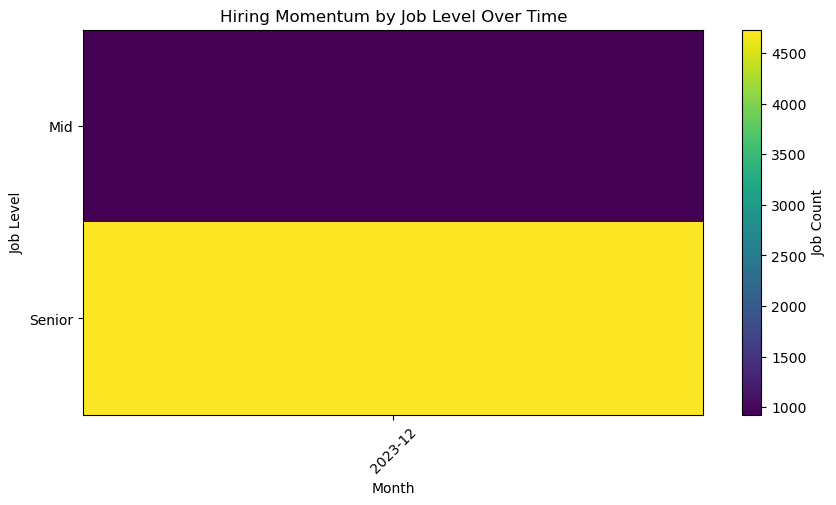

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

pivot = (
    df.groupby(['year_month', 'job_level_clean'])
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(10,5))
plt.imshow(pivot.T, aspect='auto')
plt.colorbar(label='Job Count')
plt.xticks(range(len(pivot.index)), pivot.index, rotation=45)
plt.yticks(range(len(pivot.columns)), pivot.columns)
plt.title('Hiring Momentum by Job Level Over Time')
plt.xlabel('Month')
plt.ylabel('Job Level')
plt.show()

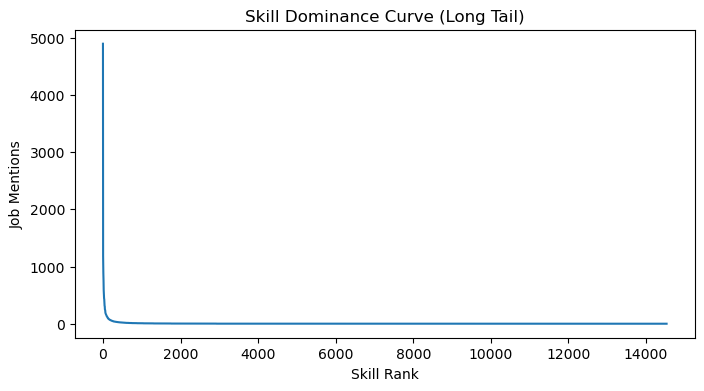

In [50]:
skill_counts = skills_df['skill_clean'].value_counts()

plt.figure(figsize=(8,4))
plt.plot(skill_counts.values)
plt.title('Skill Dominance Curve (Long Tail)')
plt.ylabel('Job Mentions')
plt.xlabel('Skill Rank')
plt.show()


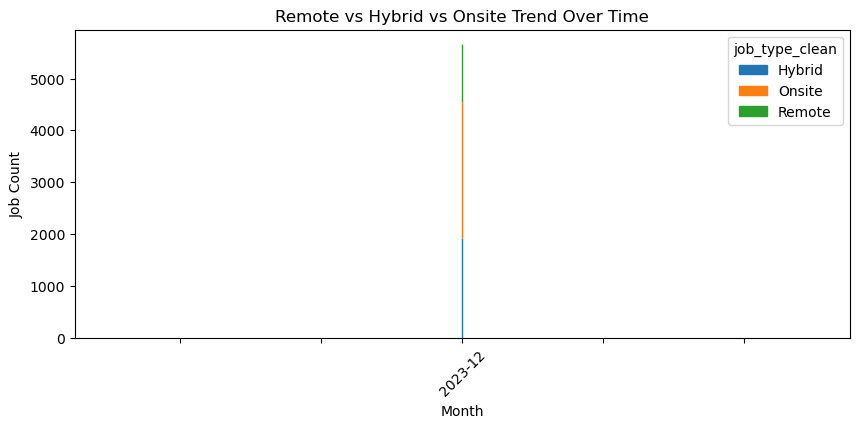

In [51]:
pivot_mode = (
    df.groupby(['year_month', 'job_type_clean'])
    .size()
    .unstack(fill_value=0)
)

pivot_mode.plot(
    kind='area',
    stacked=True,
    figsize=(10,4),
    title='Remote vs Hybrid vs Onsite Trend Over Time'
)

plt.ylabel('Job Count')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.show()

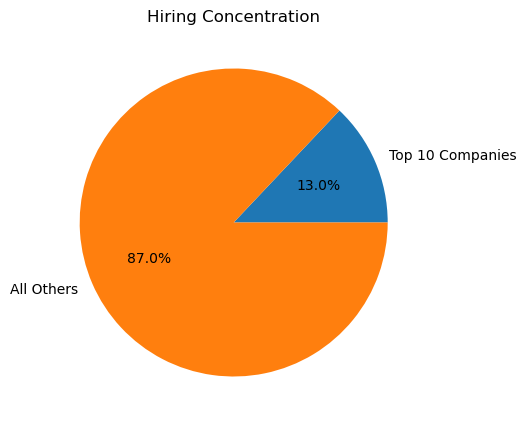

In [52]:
company_counts = df['company'].value_counts()

top_10 = company_counts.head(10).sum()
others = company_counts.iloc[10:].sum()

plt.figure(figsize=(5,5))
plt.pie(
    [top_10, others],
    labels=['Top 10 Companies', 'All Others'],
    autopct='%1.1f%%'
)
plt.title('Hiring Concentration')
plt.show()

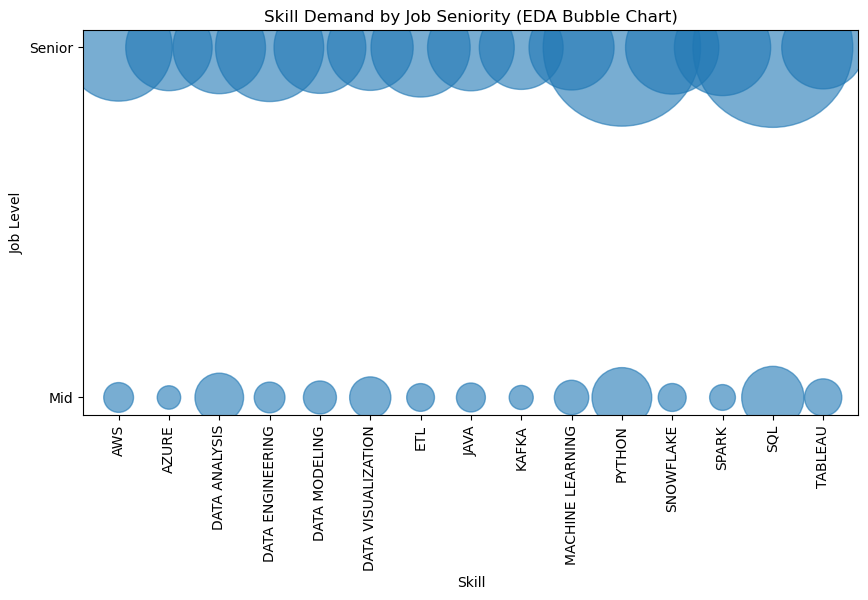

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv('postings.csv')

# Clean job level quickly (inline, no extra tables)
df['job_level'] = df['job level'].fillna('Mid').str.lower().apply(
    lambda x: 'Junior' if 'junior' in x or 'entry' in x
    else 'Senior' if 'senior' in x or 'lead' in x or 'staff' in x
    else 'Mid'
)

# Explode skills inline
skills = (
    df[['job_level', 'job_skills']]
    .dropna()
    .assign(job_skills=lambda x: x['job_skills'].str.upper().str.split(','))
    .explode('job_skills')
)

skills['job_skills'] = skills['job_skills'].str.strip()

# Focus only on top 15 skills (inline)
top_skills = skills['job_skills'].value_counts().head(15).index
skills = skills[skills['job_skills'].isin(top_skills)]

# Aggregate inline for plotting
plot_data = (
    skills.groupby(['job_skills', 'job_level'])
    .size()
    .reset_index(name='count')
)

# Bubble chart
plt.figure(figsize=(10,5))
plt.scatter(
    plot_data['job_skills'],
    plot_data['job_level'],
    s=plot_data['count'] * 5,
    alpha=0.6
)

plt.xticks(rotation=90)
plt.xlabel('Skill')
plt.ylabel('Job Level')
plt.title('Skill Demand by Job Seniority (EDA Bubble Chart)')
plt.show()


In [59]:
df.to_csv('postings1.csv', index=False)

In [61]:
check_df = pd.read_csv('postings1.csv')
check_df.head()


,job_title,company,job_location,job_link,first_seen,search_city,search_country,job level,job_type,job_summary,job_skills
0,Data Engineer 2,Cook Medical,"Bloomington, IN",https://www.linkedin.com/jobs/view/data-engine...,2023-12-17,Bloomington,United States,Mid senior,Onsite,"Overview\nThe Data Engineer develops, implemen...","Azure, SQL, NoSQL, SQL Server, Oracle, MongoDB..."
1,Staff Data Engineer,Recruiting from Scratch,"Bloomington, IN",https://www.linkedin.com/jobs/view/staff-data-...,2023-12-17,Bloomington,United States,Mid senior,Onsite,This is for a client of Recruiting from Scratc...,"Python, Snowflake, Airflow, Kubernetes, Docker..."
2,"Senior Data Engineer, Public Company",Recruiting from Scratch,"Bloomington, IN",https://www.linkedin.com/jobs/view/senior-data...,2023-12-17,Bloomington,United States,Mid senior,Onsite,This is for a client of Recruiting from Scratc...,"Python, SQL, Snowflake, Airflow, Kubernetes, D..."
3,"Senior Data Engineer, Public Company",Recruiting from Scratch,"Bloomington, IN",https://www.linkedin.com/jobs/view/senior-data...,2023-12-17,Bloomington,United States,Mid senior,Onsite,This is for a client of Recruiting from Scratc...,"TDD, Automation, Continuous delivery, Data eng..."
4,"Senior Systems Engineer, Azure Data Platform",Cook Medical,"Bloomington, IN",https://www.linkedin.com/jobs/view/senior-syst...,2023-12-17,Bloomington,United States,Mid senior,Hybrid,Overview\nWe are seeking a talented Azure Clou...,NaN


In [60]:
import os

# Show current working directory
os.getcwd()


'/Users/kushala'

In [62]:
df.to_csv('postings.csv', index=False)

In [63]:
import os
os.listdir('.')


['Untitled10.ipynb',
 '.zshrc.save',
 'Untitled7.ipynb',
 'postings.csv',
 '.config',
 'IT_Service_Desk_Data_100_Tickets.xlsx',
 'Untitled34.ipynb',
 'Music',
 'data visualization.ipynb',
 '.kaggle',
 'lab7 .ipynb',
 'data science.ipynb',
 '.condarc',
 'Untitled36.ipynb',
 'Untitled12.ipynb',
 'Regional Sales Dataset (2).xlsx',
 'Untitled5.ipynb',
 'instagram.db',
 'Untitled1.ipynb',
 'Untitled16.ipynb',
 '.DS_Store',
 'Untitled32.ipynb',
 '.CFUserTextEncoding',
 'Untitled30.ipynb',
 '.xonshrc',
 'Untitled29.ipynb',
 'anaconda_projects',
 'Untitled3.ipynb',
 'regional sales data analysis.ipynb',
 'Untitled14.ipynb',
 'Untitled.ipynb',
 'Untitled37.ipynb',
 '.zshrc',
 'lab8.ipynb',
 'postgresql_18.app.zip',
 'Untitled4.ipynb',
 'Walmart.csv',
 'Untitled13.ipynb',
 'cosmetics1.sqbpro',
 'Untitled6.ipynb',
 'Pictures',
 'Untitled11.ipynb',
 'duplicates_relationships.png',
 '.zprofile',
 'cleaned_survey_data_analyzed.csv',
 'Untitled35.ipynb',
 'Untitled31.ipynb',
 'job-postings.xlsx',
 'U